In [37]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import LabelEncoder, OrdinalEncoder, OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import precision_score, accuracy_score, classification_report, confusion_matrix, recall_score

In [38]:
df = pd.read_csv("loan_approval_data.csv")

In [39]:
df.head()

,Applicant_ID,Applicant_Income,Coapplicant_Income,Employment_Status,Age,Marital_Status,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term,Loan_Purpose,Property_Area,Education_Level,Gender,Employer_Category,Loan_Approved
0,1.0,17795.0,1387.0,Salaried,51.0,Married,0.0,637.0,4.0,0.53,19403.0,45638.0,16619.0,84.0,Personal,Urban,Not Graduate,Female,Private,No
1,2.0,2860.0,2679.0,Salaried,46.0,Married,3.0,621.0,2.0,0.30,2580.0,49272.0,38687.0,NaN,Car,Semiurban,Graduate,NaN,Private,No
2,3.0,7390.0,2106.0,Salaried,25.0,Single,2.0,674.0,4.0,0.20,13844.0,6908.0,27943.0,72.0,NaN,Urban,NaN,Female,Government,Yes
3,4.0,13964.0,8173.0,Salaried,40.0,Married,2.0,579.0,3.0,0.31,9553.0,10844.0,27819.0,60.0,Business,Rural,Graduate,Female,Government,No
4,5.0,13284.0,4223.0,Self-employed,31.0,Single,2.0,721.0,1.0,0.29,9386.0,37629.0,12741.0,72.0,Car,NaN,Graduate,Male,Private,Yes


In [40]:
df.isnull().sum()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 20 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Applicant_ID        950 non-null    float64
 1   Applicant_Income    950 non-null    float64
 2   Coapplicant_Income  950 non-null    float64
 3   Employment_Status   950 non-null    object 
 4   Age                 950 non-null    float64
 5   Marital_Status      950 non-null    object 
 6   Dependents          950 non-null    float64
 7   Credit_Score        950 non-null    float64
 8   Existing_Loans      950 non-null    float64
 9   DTI_Ratio           950 non-null    float64
 10  Savings             950 non-null    float64
 11  Collateral_Value    950 non-null    float64
 12  Loan_Amount         950 non-null    float64
 13  Loan_Term           950 non-null    float64
 14  Loan_Purpose        950 non-null    object 
 15  Property_Area       950 non-null    object 
 16  Educati

In [41]:
numerical_cols = df.select_dtypes("number").columns
categorical_cols = df.select_dtypes("object").columns

In [42]:
# Handle Missing Values
num_imp = SimpleImputer(strategy="mean")
df[numerical_cols] = num_imp.fit_transform(df[numerical_cols])

cat_imp = SimpleImputer(strategy="most_frequent")
df[categorical_cols] = cat_imp.fit_transform(df[categorical_cols])

<Axes: xlabel='Applicant_Income', ylabel='Count'>

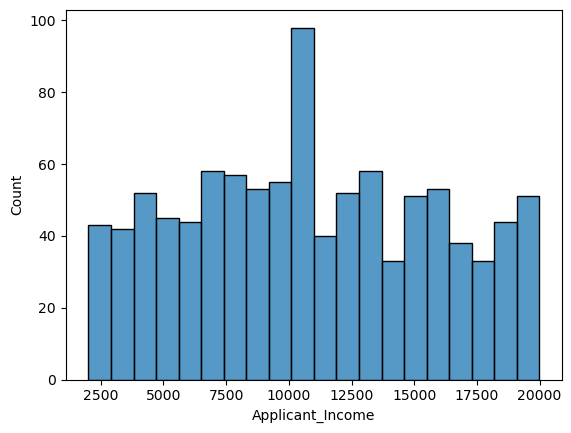

In [43]:
# Data Visualization

sns.histplot(
    data=df,
    x="Applicant_Income",
    bins=20
)

<Axes: xlabel='Credit_Score', ylabel='Count'>

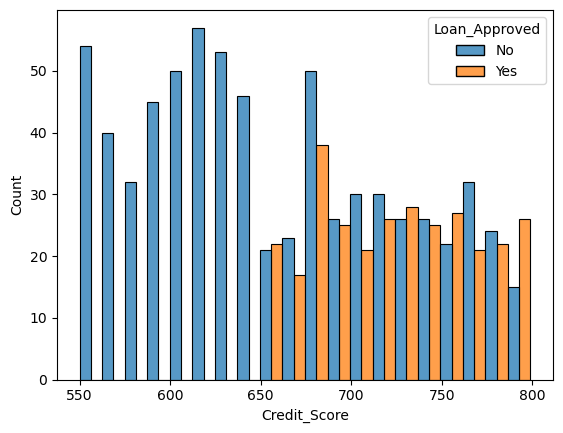

In [44]:
sns.histplot(
    data=df,
    x="Credit_Score",
    hue="Loan_Approved",
    bins=20,
    multiple="dodge"
    
)

<Axes: xlabel='DTI_Ratio', ylabel='Count'>

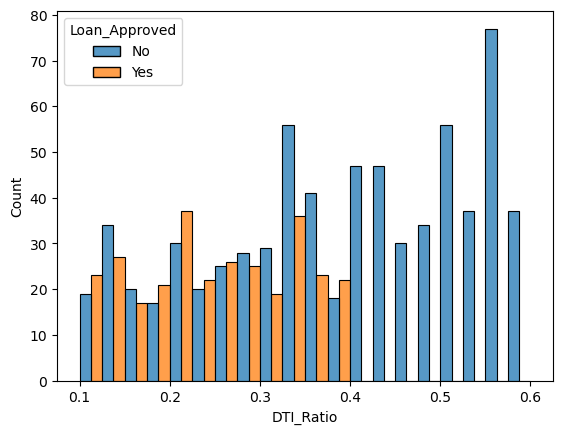

In [45]:
sns.histplot(
    data=df,
    x="DTI_Ratio",
    hue="Loan_Approved",
    bins=20,
    multiple="dodge"
    
)

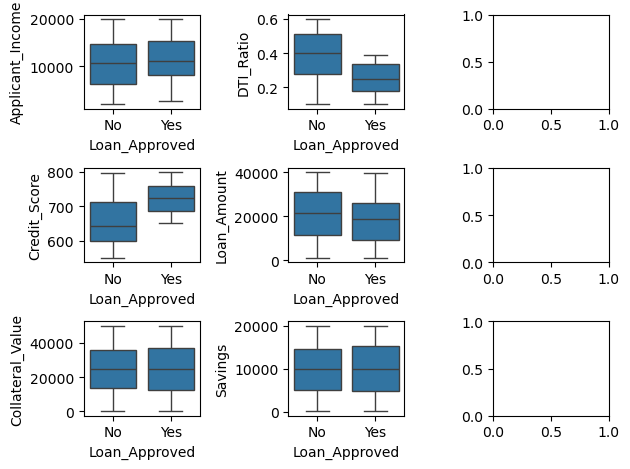

In [46]:
fig, axes = plt.subplots(3, 3)

sns.boxplot(ax = axes[0,0], data=df, x="Loan_Approved", y="Applicant_Income")
sns.boxplot(ax = axes[0,1], data=df, x="Loan_Approved", y="DTI_Ratio")
sns.boxplot(ax = axes[1,0], data=df, x="Loan_Approved", y="Credit_Score")
sns.boxplot(ax = axes[1,1], data=df, x="Loan_Approved", y="Loan_Amount")
sns.boxplot(ax = axes[2,0], data=df, x="Loan_Approved", y="Collateral_Value")
sns.boxplot(ax = axes[2,1], data=df, x="Loan_Approved", y="Savings")

plt.tight_layout()

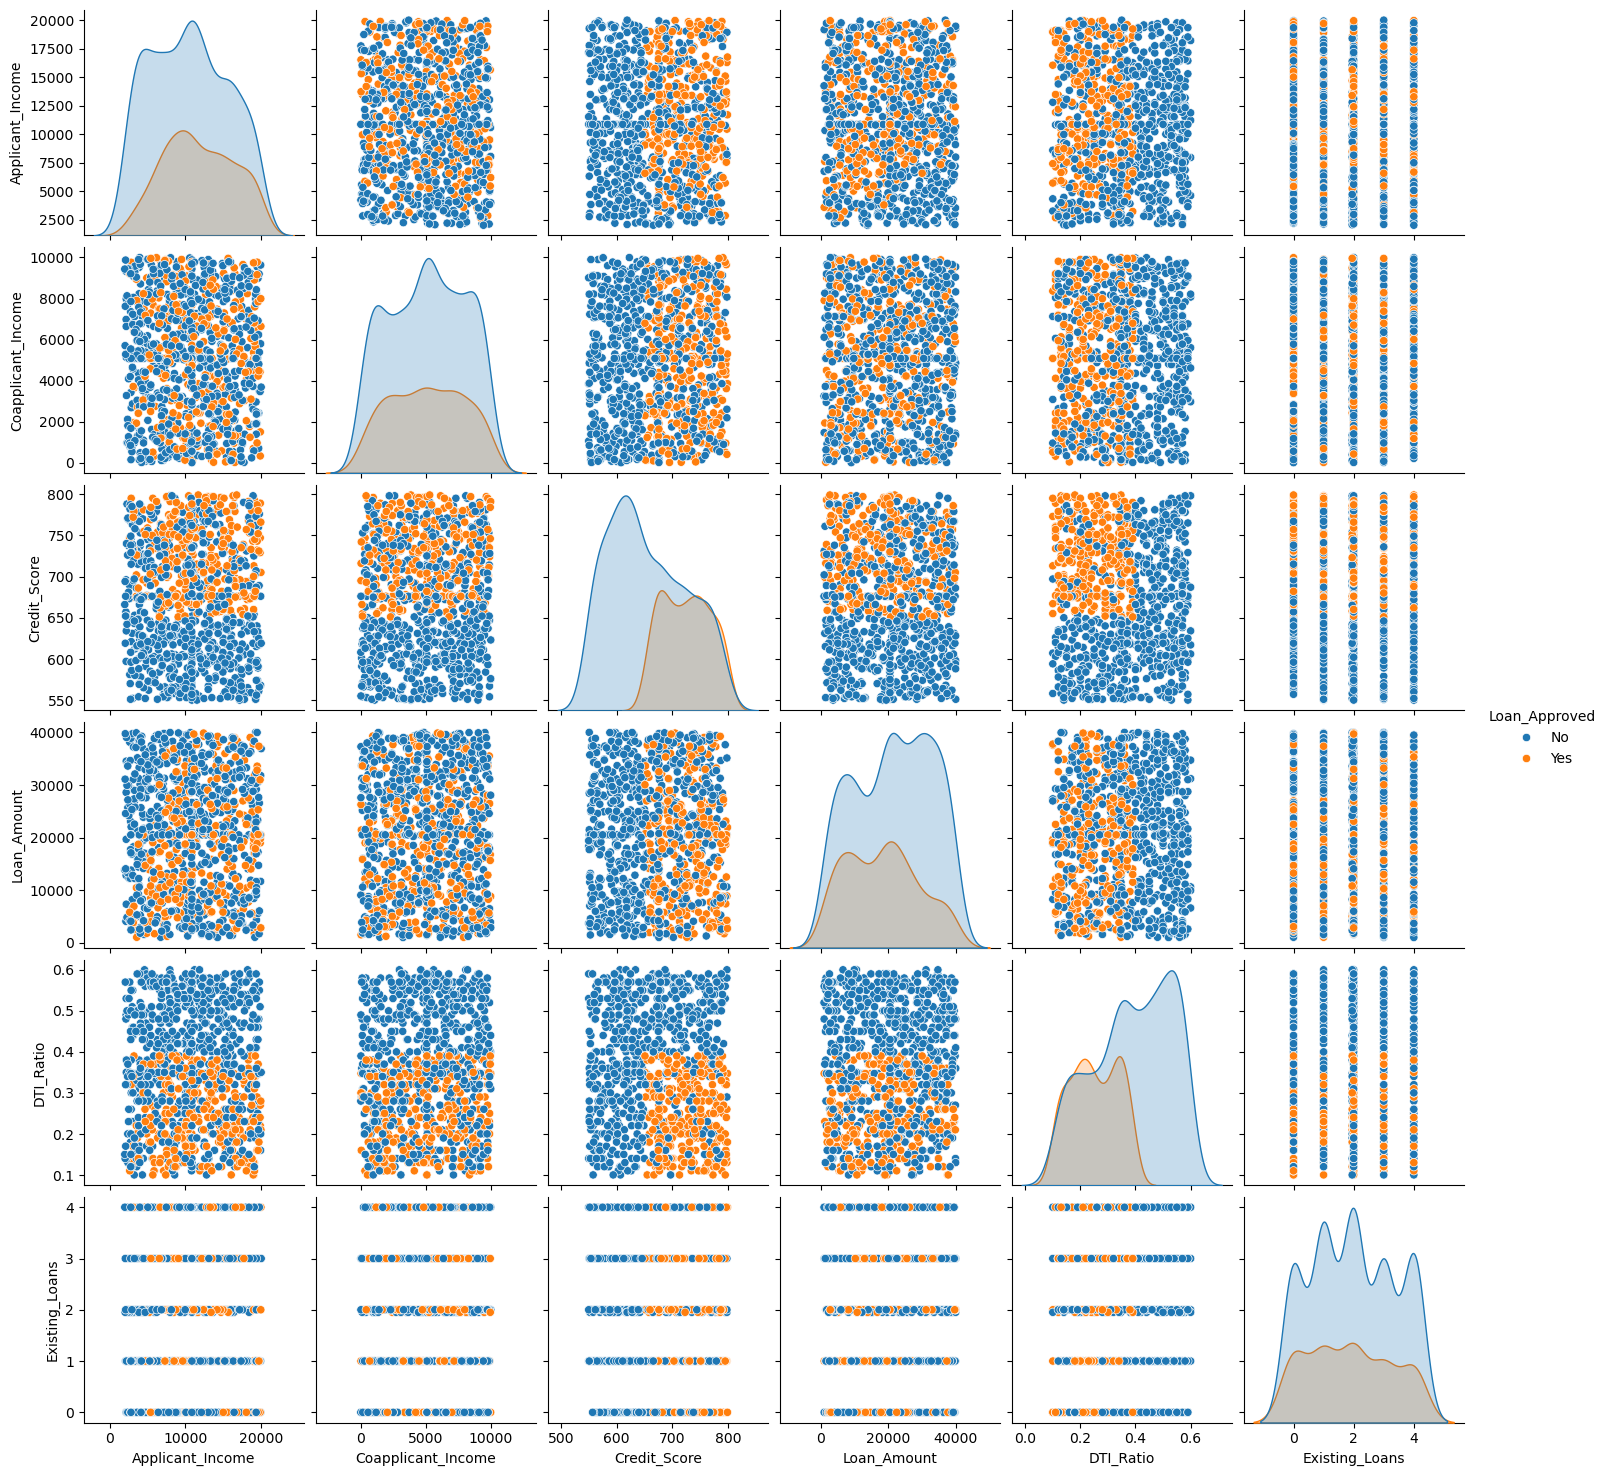

In [47]:
df.select_dtypes("number").columns
numeric_df = ["Applicant_Income", "Coapplicant_Income", "Credit_Score", "Loan_Amount", "DTI_Ratio", "Existing_Loans"] 
sns.pairplot(df[numeric_df + ["Loan_Approved"]], hue="Loan_Approved")

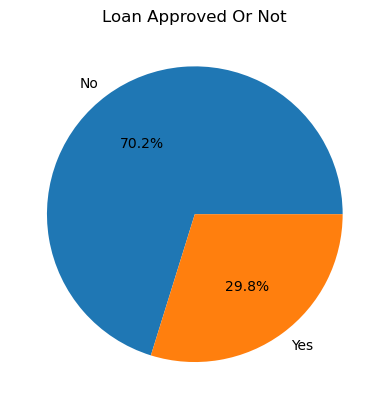

In [48]:
classes = df["Loan_Approved"].value_counts()
plt.pie(classes, labels=["No", "Yes"], autopct="%1.1f%%")
plt.title("Loan Approved Or Not")
plt.show()

# Encoding on categorical features

In [49]:
# Label Encoding 

le = LabelEncoder()
df["Loan_Approved"] = le.fit_transform(df["Loan_Approved"])

# Ordinal Encoding 
oe = OrdinalEncoder(categories=[["Not Graduate", "Graduate"]])
df[["Education_Level"]] = oe.fit_transform(df[["Education_Level"]])

# One Hot Encoding
cols = ['Employment_Status', 'Marital_Status', 'Loan_Purpose', 'Property_Area', 'Gender', 'Employer_Category']
ohe = OneHotEncoder(drop="first", sparse_output=False, handle_unknown="ignore")
encoded = ohe.fit_transform(df[cols])
encoded_df = pd.DataFrame(encoded, columns=ohe.get_feature_names_out(cols), index=df.index)
df = pd.concat([df.drop(cols, axis=1), encoded_df], axis=1)
df = df.drop("Applicant_ID", axis=1)

In [50]:
df.columns

Index(['Applicant_Income', 'Coapplicant_Income', 'Age', 'Dependents',
       'Credit_Score', 'Existing_Loans', 'DTI_Ratio', 'Savings',
       'Collateral_Value', 'Loan_Amount', 'Loan_Term', 'Education_Level',
       'Loan_Approved', 'Employment_Status_Salaried',
       'Employment_Status_Self-employed', 'Employment_Status_Unemployed',
       'Marital_Status_Single', 'Loan_Purpose_Car', 'Loan_Purpose_Education',
       'Loan_Purpose_Home', 'Loan_Purpose_Personal', 'Property_Area_Semiurban',
       'Property_Area_Urban', 'Gender_Male', 'Employer_Category_Government',
       'Employer_Category_MNC', 'Employer_Category_Private',
       'Employer_Category_Unemployed'],
      dtype='object')

In [51]:
df["Education_Level"].value_counts()    

Education_Level
1.0    722
0.0    278
Name: count, dtype: int64

In [52]:
df.groupby("Education_Level")["Loan_Approved"].mean()

Education_Level
0.0    0.258993
1.0    0.313019
Name: Loan_Approved, dtype: float64

# Correlation Heatmap

In [53]:
corr_matrix = df.corr()
corr_matrix["Loan_Approved"].sort_values(ascending=False)

Loan_Approved                      1.000000
Credit_Score                       0.451175
Applicant_Income                   0.119796
Employer_Category_MNC              0.069049
Education_Level                    0.052920
Loan_Purpose_Personal              0.034043
Marital_Status_Single              0.030182
Property_Area_Urban                0.025963
Collateral_Value                   0.021868
Coapplicant_Income                 0.004230
Loan_Purpose_Home                  0.002118
Employment_Status_Self-employed   -0.001337
Employer_Category_Private         -0.003347
Property_Area_Semiurban           -0.012967
Savings                           -0.013437
Loan_Purpose_Education            -0.016684
Employer_Category_Unemployed      -0.021468
Age                               -0.022343
Dependents                        -0.023811
Existing_Loans                    -0.034794
Employer_Category_Government      -0.039187
Employment_Status_Salaried        -0.041428
Employment_Status_Unemployed    

<Axes: >

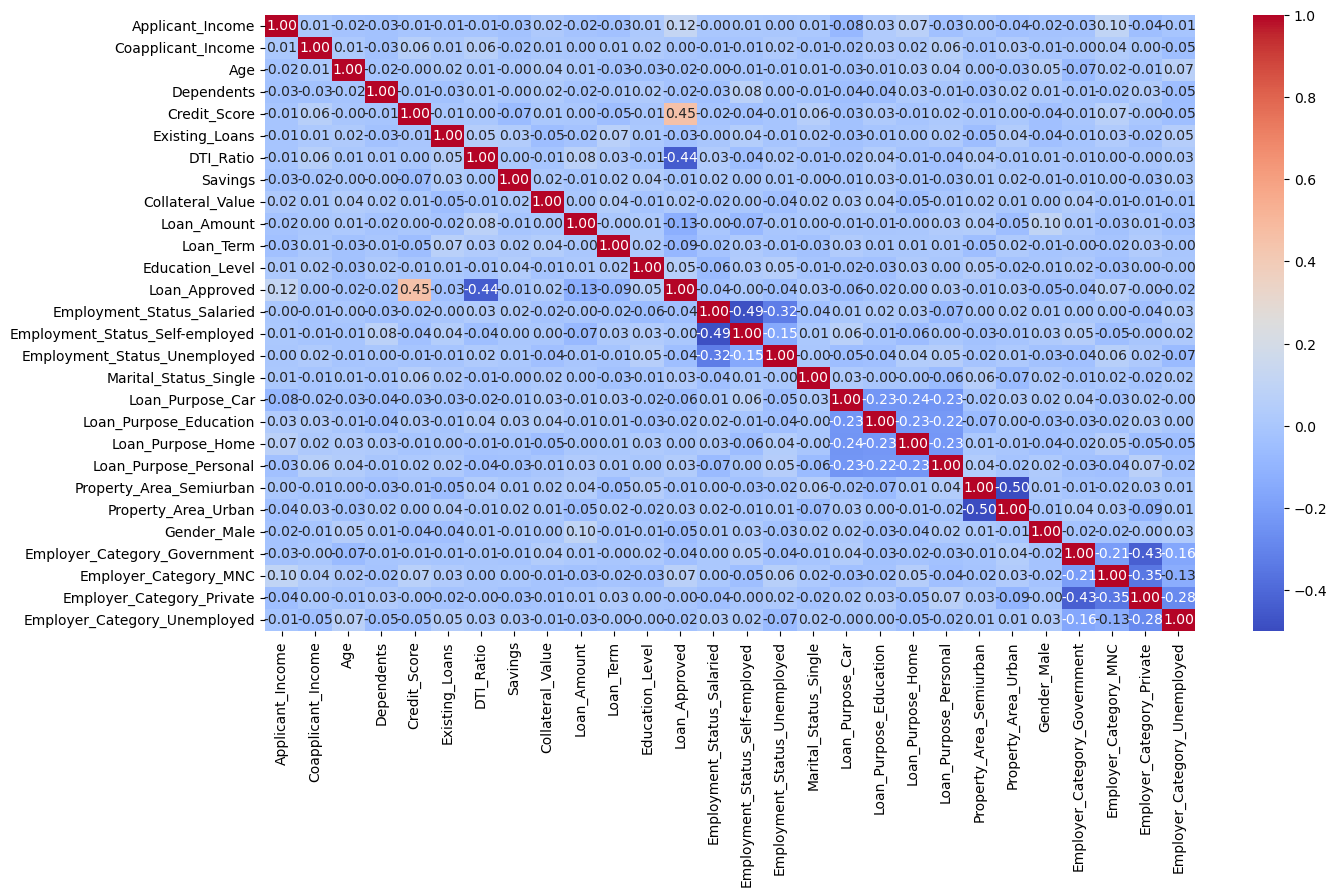

In [54]:
plt.figure(figsize=(15,8))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

In [55]:
X = df.drop("Loan_Approved", axis=1)
y = df["Loan_Approved"]

In [56]:
# Train Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

In [57]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Training Models

In [58]:
# Logistic regression
from sklearn.linear_model import LogisticRegression
lr = LogisticRegression(C=0.04)
lr.fit(X_train_scaled, y_train)

y_test_pred = lr.predict(X_test_scaled)
y_train_pred = lr.predict(X_train_scaled)

print(f"Training Accuracy: {accuracy_score(y_train, y_train_pred)}")
print(f"Testing Accuracy: {accuracy_score(y_test, y_test_pred)}")

print(f"Precision Score: {precision_score(y_test, y_test_pred)}")
print(f"Classification report: {classification_report(y_test, y_test_pred)}")
print("confusion matrix", confusion_matrix(y_test, y_test_pred))

Training Accuracy: 0.85875
Testing Accuracy: 0.865
Precision Score: 0.8269230769230769
Classification report:               precision    recall  f1-score   support

           0       0.88      0.94      0.91       139
           1       0.83      0.70      0.76        61

    accuracy                           0.86       200
   macro avg       0.85      0.82      0.83       200
weighted avg       0.86      0.86      0.86       200

confusion matrix [[130   9]
 [ 18  43]]


In [59]:
# Naive Bayes
from sklearn.naive_bayes import GaussianNB
gnb = GaussianNB()
gnb.fit(X_train, y_train)

y_train_pred = gnb.predict(X_train)
y_test_pred = gnb.predict(X_test)

print(f"Training Accuracy: {accuracy_score(y_train, y_train_pred)}")
print(f"Testing Accuracy: {accuracy_score(y_test, y_test_pred)}")

print(f"Precision Score: {precision_score(y_test, y_test_pred)}")
print(f"Classification report: {classification_report(y_test, y_test_pred)}")
print("confusion matrix", confusion_matrix(y_test, y_test_pred))

Training Accuracy: 0.78375
Testing Accuracy: 0.74
Precision Score: 0.576271186440678
Classification report:               precision    recall  f1-score   support

           0       0.81      0.82      0.81       139
           1       0.58      0.56      0.57        61

    accuracy                           0.74       200
   macro avg       0.69      0.69      0.69       200
weighted avg       0.74      0.74      0.74       200

confusion matrix [[114  25]
 [ 27  34]]


In [66]:
# KNN Classifier
from sklearn.model_selection import GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier()
params = {"n_neighbors" : [3, 5, 7, 9, 11]}

grid = GridSearchCV(estimator=knn, param_grid=params, scoring="f1", cv=5)

grid.fit(X_train_scaled, y_train)
y_test_pred = grid.predict(X_test_scaled)
y_train_pred = grid.predict(X_train_scaled)

print(f"Training Accuracy: {accuracy_score(y_train, y_train_pred)}")
print(f"Testing Accuracy: {accuracy_score(y_test, y_test_pred)}")

print(f"Precision Score: {precision_score(y_test, y_test_pred)}")
print(f"Classification report: {classification_report(y_test, y_test_pred)}")
print("confusion matrix", confusion_matrix(y_test, y_test_pred))

print(grid.best_params_)
print(grid.best_score_)

Training Accuracy: 0.885
Testing Accuracy: 0.74
Precision Score: 0.5737704918032787
Classification report:               precision    recall  f1-score   support

           0       0.81      0.81      0.81       139
           1       0.57      0.57      0.57        61

    accuracy                           0.74       200
   macro avg       0.69      0.69      0.69       200
weighted avg       0.74      0.74      0.74       200

confusion matrix [[113  26]
 [ 26  35]]
{'n_neighbors': 3}
0.584876258866117


In [64]:
# SVC
from sklearn.svm import SVC
svc = SVC()
params = {
    "kernel" : ["rbf", "poly", "sigmoid"],
     "C" : [0.1, 0.01,  2, 3, 4, 5]
}
grid = GridSearchCV(estimator=svc, param_grid=params, scoring="f1", cv=5)

grid.fit(X_train_scaled, y_train)
y_test_pred = grid.predict(X_test_scaled)
y_train_pred = grid.predict(X_train_scaled)

print(f"Training Accuracy: {accuracy_score(y_train, y_train_pred)}")
print(f"Testing Accuracy: {accuracy_score(y_test, y_test_pred)}")

print(f"Precision Score: {precision_score(y_test, y_test_pred)}")
print(f"Classification report: {classification_report(y_test, y_test_pred)}")
print("confusion matrix", confusion_matrix(y_test, y_test_pred))

print(grid.best_params_)
print(grid.best_score_)

Training Accuracy: 0.98
Testing Accuracy: 0.87
Precision Score: 0.8070175438596491
Classification report:               precision    recall  f1-score   support

           0       0.90      0.92      0.91       139
           1       0.81      0.75      0.78        61

    accuracy                           0.87       200
   macro avg       0.85      0.84      0.84       200
weighted avg       0.87      0.87      0.87       200

confusion matrix [[128  11]
 [ 15  46]]
{'C': 2, 'kernel': 'rbf'}
0.7759736962478965
